# Combinaisons non linéaires induites par machine

## Objectif du notebook

Ce notebook transforme le concept EBTA de **Machine-Induced Nonlinear Combinations** en une démonstration pédagogique et opérationnelle.

L'idée centrale est simple :

> Plus un modèle devient capable de capturer des interactions complexes, plus il devient capable de capturer du bruit.

Le but n'est donc pas de créer le modèle le plus complexe possible, mais de trouver le niveau de complexité qui généralise le mieux.

Dans ce notebook, on va simuler un cas de trading où :

- un signal faible existe réellement ;
- les features sont bruitées ;
- les modèles simples sous-exploitent l'information ;
- les modèles trop complexes surapprennent ;
- le protocole **Train / Test / Validation** permet de séparer recherche, sélection et estimation finale.

## 1. L'idée EBTA en une phrase

Dans le cadre EBTA de David Aronson, les modèles non linéaires induits par machine servent à combiner plusieurs indicateurs techniques d'une manière que l'humain ne peut pas facilement formuler à la main.

Un modèle linéaire dit implicitement :

$$
\text{Signal} = a \times \text{Indicateur}_1 + b \times \text{Indicateur}_2 + c
$$

Un modèle non linéaire peut dire :

$$
\text{Signal} = f(\text{Indicateur}_1, \text{Indicateur}_2, \text{Indicateur}_3, ...)
$$

La différence est énorme.

Dans le second cas, la contribution d'un indicateur peut dépendre de la valeur d'un autre indicateur.

> Exemple trading : un RSI bas peut être haussier en régime de tendance haussière, mais dangereux en régime baissier violent.

## 2. Pourquoi la non-linéarité est utile en trading

Les marchés sont rarement gouvernés par une relation stable et additive.

Une même condition peut avoir un sens différent selon le contexte.

| Condition isolée | Interprétation naïve | Interprétation contextuelle |
|---|---:|---:|
| RSI bas | Achat | Achat seulement si le régime est favorable |
| Prix au-dessus d'une moyenne mobile | Momentum haussier | Momentum fragile si volatilité extrême |
| Volatilité élevée | Risque | Opportunité si cassure confirmée |
| Retour vers VWAP | Mean reversion | Momentum si le flux reste directionnel |

Le modèle non linéaire cherche précisément ces interactions.

Mais c'est aussi le danger : plus on donne de liberté au modèle, plus il peut fabriquer une explication parfaite du passé.

## 3. Le protocole tripartite

Le passage clé d'Aronson repose sur trois fenêtres de données.

| Segment | Rôle | Question posée | Danger si mal utilisé |
|---|---|---|---|
| **Training** | Ajuster les paramètres internes | Quels paramètres maximisent l'apprentissage ? | Overfitting local |
| **Testing** | Choisir la complexité | Quel niveau de complexité généralise le mieux ? | Biais de sélection |
| **Validation** | Estimation finale | Que vaut le modèle final sur des données vierges ? | Données brûlées si réutilisées |

> Le **Test** n'est pas une preuve finale. C'est un segment de sélection.

> La **Validation** est le juge final, car elle n'a pas été utilisée dans la découverte.

## 4. Simulation : créer un marché avec interaction non linéaire

On va créer une série de prix synthétique.

Le rendement futur dépendra faiblement d'une interaction entre deux variables :

- une feature de **momentum** ;
- une feature de **reversal** ;
- une feature de **volatilité**.

La règle cachée sera volontairement non linéaire : le momentum ne fonctionne que dans certains régimes de volatilité et de reversal.

Cela permet d'illustrer pourquoi un modèle trop simple peut manquer une partie du signal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 3000
index = pd.date_range("2015-01-01", periods=n, freq="D")

# Bruit de marché
noise = np.random.normal(0, 0.01, size=n)

# Features synthétiques, connues à la date t
momentum_feature = np.random.normal(0, 1, size=n)
reversal_feature = np.random.normal(0, 1, size=n)
volatility_feature = np.random.normal(0, 1, size=n)

# Interaction non linéaire cachée
# Le momentum est surtout utile quand la volatilité est modérée
# et quand la pression de reversal n'est pas extrême.
hidden_edge = (
    0.004 * np.tanh(momentum_feature)
    * (volatility_feature < 0.7)
    * (reversal_feature > -0.8)
)

# Rendement futur simulé
returns = noise + hidden_edge
price = 100 * np.exp(np.cumsum(returns))

data = pd.DataFrame({
    "price": price,
    "returns": returns,
    "momentum": momentum_feature,
    "reversal": reversal_feature,
    "volatility": volatility_feature,
}, index=index)

data.head()

,price,returns,momentum,reversal,volatility
2015-01-01,100.497950,0.004967,-1.907808,-1.114081,0.765402
2015-01-02,100.359093,-0.001383,-0.860385,-0.630931,1.073413
2015-01-03,101.011217,0.006477,-0.413606,-0.942060,0.498690
2015-01-04,102.954027,0.019051,1.887688,-0.547996,-1.942498
2015-01-05,102.921101,-0.000320,0.556553,-0.214150,-0.155422


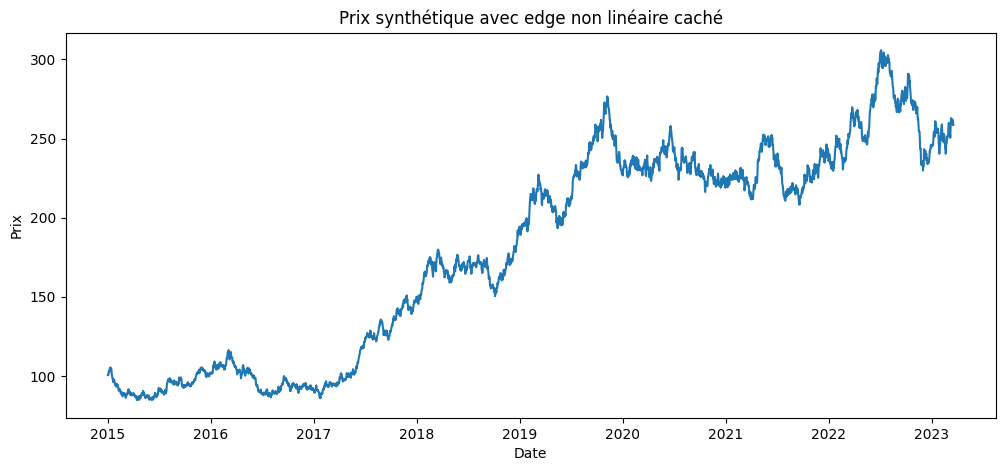

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["price"])
plt.title("Prix synthétique avec edge non linéaire caché")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

## 5. Construire les labels de trading

Pour transformer ce problème en stratégie, on prédit le signe du rendement suivant.

Le modèle ne voit que les features à la date $t$.

La cible est :

$$
y_{t+1} = \mathbb{1}(r_{t+1} > 0)
$$

Ensuite, le signal de trading sera :

$$
\text{position}_t =
\begin{cases}
+1 & \text{si le modèle prédit une hausse} \\
-1 & \text{sinon}
\end{cases}
$$

Pour éviter le **look-ahead bias**, les positions sont décalées d'une période avant de calculer la performance.

In [3]:
features = ["momentum", "reversal", "volatility"]

model_data = data.copy()
model_data["target"] = (model_data["returns"].shift(-1) > 0).astype(int)
model_data = model_data.dropna()

X = model_data[features]
y = model_data["target"]
future_returns = model_data["returns"].shift(-1).dropna()

# Alignement final
X = X.loc[future_returns.index]
y = y.loc[future_returns.index]

X.head(), y.head()

(            momentum  reversal  volatility
 2015-01-01 -1.907808 -1.114081    0.765402
 2015-01-02 -0.860385 -0.630931    1.073413
 2015-01-03 -0.413606 -0.942060    0.498690
 2015-01-04  1.887688 -0.547996   -1.942498
 2015-01-05  0.556553 -0.214150   -0.155422,
 2015-01-01    0
 2015-01-02    1
 2015-01-03    1
 2015-01-04    0
 2015-01-05    0
 Freq: D, Name: target, dtype: int64)

## 6. Découpage Train / Test / Validation

On découpe chronologiquement les données.

Important : on ne mélange pas les observations, car en trading l'ordre temporel est essentiel.

| Segment | Pourcentage | Usage |
|---|---:|---|
| Training | 50\% | Ajustement des paramètres du modèle |
| Testing | 25\% | Choix du niveau de complexité |
| Validation | 25\% | Estimation finale non biaisée |

In [4]:
n_obs = len(X)
train_end = int(n_obs * 0.50)
test_end = int(n_obs * 0.75)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_test, y_test = X.iloc[train_end:test_end], y.iloc[train_end:test_end]
X_val, y_val = X.iloc[test_end:], y.iloc[test_end:]

ret_train = future_returns.iloc[:train_end]
ret_test = future_returns.iloc[train_end:test_end]
ret_val = future_returns.iloc[test_end:]

print("Train:", X_train.index.min().date(), "→", X_train.index.max().date(), len(X_train))
print("Test:", X_test.index.min().date(), "→", X_test.index.max().date(), len(X_test))
print("Validation:", X_val.index.min().date(), "→", X_val.index.max().date(), len(X_val))

Train: 2015-01-01 → 2019-02-07 1499
Test: 2019-02-08 → 2021-02-26 750
Validation: 2021-02-27 → 2023-03-18 750


## 7. Fonction de backtest minimaliste

On va mesurer une stratégie long/short très simple.

Elle n'est pas un moteur de backtest institutionnel, mais elle suffit pour l'idée pédagogique.

Mesures utilisées :

- rendement cumulé ;
- Sharpe annualisé simplifié ;
- drawdown maximum ;
- accuracy directionnelle.

La formule du Sharpe annualisé simplifié est :

$$
\text{Sharpe} = \frac{\mathbb{E}[r_s]}{\sigma(r_s)} \times \sqrt{252}
$$

où $r_s$ représente les rendements de la stratégie.

In [5]:
def compute_metrics(strategy_returns: pd.Series, predictions: pd.Series, true_labels: pd.Series) -> dict:
    strategy_returns = strategy_returns.dropna()
    equity = (1 + strategy_returns).cumprod()
    drawdown = equity / equity.cummax() - 1
    sharpe = np.nan
    if strategy_returns.std() > 0:
        sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
    accuracy = (predictions.loc[true_labels.index] == true_labels).mean()
    return {
        "total_return": equity.iloc[-1] - 1,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
        "accuracy": accuracy,
    }


def backtest_predictions(predictions: pd.Series, realized_returns: pd.Series) -> pd.Series:
    # 1 = long, 0 = short
    position = predictions.replace({1: 1, 0: -1})
    strategy_returns = position * realized_returns.loc[position.index]
    return strategy_returns.dropna()

## 8. Comparer plusieurs niveaux de complexité

Pour illustrer l'optimisation de la complexité, on utilise des arbres de décision.

Pourquoi ? Parce qu'ils permettent de contrôler intuitivement la complexité avec `max_depth`.

| `max_depth` | Interprétation |
|---:|---|
| 1 | Règle très simple |
| 2 à 4 | Interactions limitées |
| 5 à 8 | Modèle plus flexible |
| 10+ | Risque élevé d'apprentissage du bruit |

Dans l'esprit EBTA :

- on entraîne chaque niveau sur **Training** ;
- on compare les niveaux sur **Testing** ;
- on garde le meilleur niveau de complexité ;
- on évalue une seule fois sur **Validation**.

In [6]:
try:
    from sklearn.tree import DecisionTreeClassifier
    sklearn_available = True
except ImportError:
    sklearn_available = False
    print("scikit-learn n'est pas installé dans cet environnement.")

results = []
models = {}

if sklearn_available:
    for depth in range(1, 16):
        model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=30, random_state=42)
        model.fit(X_train, y_train)
        
        pred_train = pd.Series(model.predict(X_train), index=X_train.index)
        pred_test = pd.Series(model.predict(X_test), index=X_test.index)
        
        strat_train = backtest_predictions(pred_train, ret_train)
        strat_test = backtest_predictions(pred_test, ret_test)
        
        train_metrics = compute_metrics(strat_train, pred_train, y_train)
        test_metrics = compute_metrics(strat_test, pred_test, y_test)
        
        results.append({
            "max_depth": depth,
            "train_sharpe": train_metrics["sharpe"],
            "test_sharpe": test_metrics["sharpe"],
            "train_return": train_metrics["total_return"],
            "test_return": test_metrics["total_return"],
            "train_accuracy": train_metrics["accuracy"],
            "test_accuracy": test_metrics["accuracy"],
        })
        models[depth] = model

    results_df = pd.DataFrame(results)
    results_df

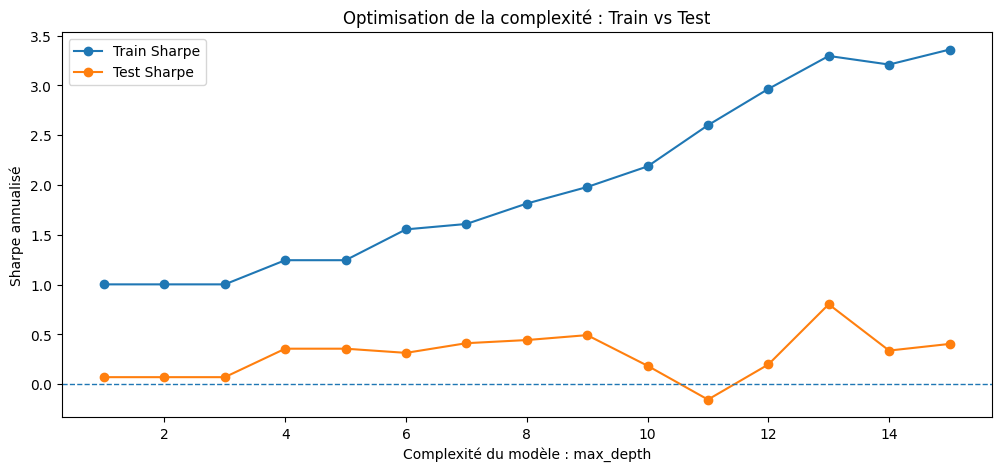

In [7]:
if sklearn_available:
    plt.figure(figsize=(12, 5))
    plt.plot(results_df["max_depth"], results_df["train_sharpe"], marker="o", label="Train Sharpe")
    plt.plot(results_df["max_depth"], results_df["test_sharpe"], marker="o", label="Test Sharpe")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Optimisation de la complexité : Train vs Test")
    plt.xlabel("Complexité du modèle : max_depth")
    plt.ylabel("Sharpe annualisé")
    plt.legend()
    plt.show()

## 9. Lire la courbe comme Aronson

La courbe typique de l'overfitting ressemble à ceci :

- la performance **Training** continue souvent de monter avec la complexité ;
- la performance **Testing** monte au début, puis plafonne ou baisse ;
- le sommet du **Testing** indique le meilleur compromis observé entre apprentissage et généralisation.

> Le modèle qui gagne sur Training n'est pas forcément le meilleur. Le modèle qui gagne sur Test est le candidat final, mais son score Test reste biaisé positivement par la sélection.

C'est pour cela que la Validation doit rester vierge jusqu'à la fin.

In [8]:
if sklearn_available:
    best_depth = int(results_df.loc[results_df["test_sharpe"].idxmax(), "max_depth"])
    best_model = models[best_depth]
    print(f"Complexité sélectionnée sur Test : max_depth = {best_depth}")

Complexité sélectionnée sur Test : max_depth = 13


## 10. Validation finale : une seule exécution

Maintenant seulement, on utilise le segment Validation.

Ce segment n'a servi ni à entraîner les paramètres, ni à sélectionner la complexité.

C'est donc l'estimation la plus honnête de la performance future simulée.

In [9]:
if sklearn_available:
    pred_train = pd.Series(best_model.predict(X_train), index=X_train.index)
    pred_test = pd.Series(best_model.predict(X_test), index=X_test.index)
    pred_val = pd.Series(best_model.predict(X_val), index=X_val.index)

    strat_train = backtest_predictions(pred_train, ret_train)
    strat_test = backtest_predictions(pred_test, ret_test)
    strat_val = backtest_predictions(pred_val, ret_val)

    summary = pd.DataFrame([
        {"segment": "Train", **compute_metrics(strat_train, pred_train, y_train)},
        {"segment": "Test", **compute_metrics(strat_test, pred_test, y_test)},
        {"segment": "Validation", **compute_metrics(strat_val, pred_val, y_val)},
    ])

    summary

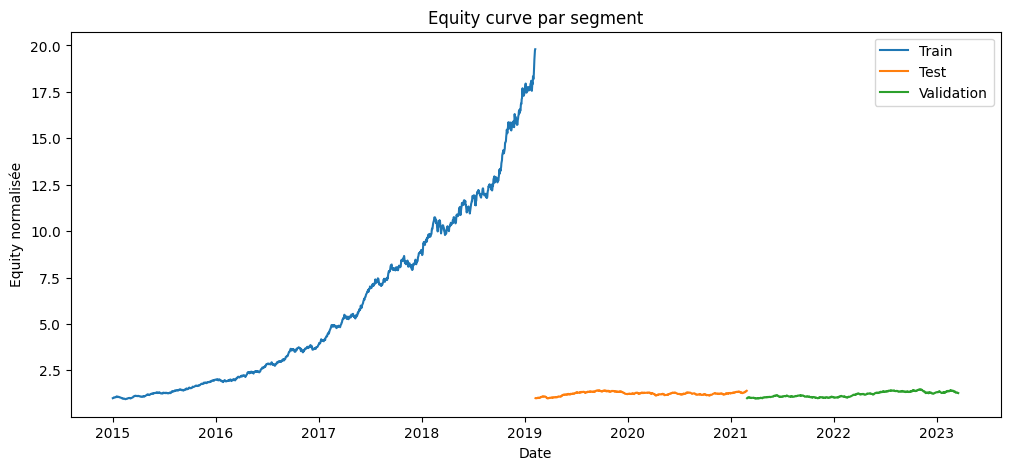

In [10]:
if sklearn_available:
    equity_train = (1 + strat_train).cumprod()
    equity_test = (1 + strat_test).cumprod()
    equity_val = (1 + strat_val).cumprod()

    plt.figure(figsize=(12, 5))
    plt.plot(equity_train.index, equity_train / equity_train.iloc[0], label="Train")
    plt.plot(equity_test.index, equity_test / equity_test.iloc[0], label="Test")
    plt.plot(equity_val.index, equity_val / equity_val.iloc[0], label="Validation")
    plt.title("Equity curve par segment")
    plt.xlabel("Date")
    plt.ylabel("Equity normalisée")
    plt.legend()
    plt.show()

## 11. Le piège : brûler la validation

Une erreur fréquente consiste à regarder la Validation, puis à modifier le modèle.

Exemples :

- ajouter un filtre RSI après avoir vu que la Validation baisse ;
- changer `max_depth` parce que la Validation n'est pas assez belle ;
- supprimer une période défavorable après coup ;
- choisir le modèle qui maximise Train + Test + Validation.

Dans ce cas, la Validation n'est plus une validation.

Elle devient un nouveau segment de recherche.

> Une donnée utilisée pour décider n'est plus une donnée vierge.

## 12. Exemple de mauvaise pratique : choisir sur Validation

Dans la cellule suivante, on montre volontairement une mauvaise pratique.

On regarde toutes les complexités sur Validation et on choisit la meilleure.

Le résultat peut sembler meilleur, mais il est contaminé par le **data mining bias**.

In [11]:
if sklearn_available:
    bad_results = []

    for depth, model in models.items():
        pred_val_tmp = pd.Series(model.predict(X_val), index=X_val.index)
        strat_val_tmp = backtest_predictions(pred_val_tmp, ret_val)
        val_metrics = compute_metrics(strat_val_tmp, pred_val_tmp, y_val)
        bad_results.append({
            "max_depth": depth,
            "validation_sharpe": val_metrics["sharpe"],
            "validation_return": val_metrics["total_return"],
        })

    bad_results_df = pd.DataFrame(bad_results)
    bad_best_depth = int(bad_results_df.loc[bad_results_df["validation_sharpe"].idxmax(), "max_depth"])

    print("Mauvaise pratique : choisir la complexité sur Validation")
    print(f"Complexité choisie à tort : max_depth = {bad_best_depth}")
    bad_results_df

Mauvaise pratique : choisir la complexité sur Validation
Complexité choisie à tort : max_depth = 14


## 13. Checklist opérationnelle EBTA pour modèle ML

Avant de lancer une recherche ML sur une stratégie de trading, tu peux utiliser cette checklist.

| Étape | Question | Validation |
|---|---|---:|
| Définition de l'univers | Quelles features sont autorisées avant la recherche ? | Oui / Non |
| Séparation des données | Train, Test, Validation sont-ils figés avant recherche ? | Oui / Non |
| Boucle interne | Les paramètres sont-ils ajustés uniquement sur Train ? | Oui / Non |
| Boucle externe | La complexité est-elle choisie uniquement sur Test ? | Oui / Non |
| Validation finale | La Validation est-elle utilisée une seule fois ? | Oui / Non |
| Journal de recherche | Toutes les variantes testées sont-elles conservées ? | Oui / Non |
| Correction data mining | WRC, MCPM ou autre correction sont-ils prévus pour l'univers de règles ? | Oui / Non |
| Incubation live | Le modèle est-il observé en paper/live avant capital sérieux ? | Oui / Non |

> L'objectif n'est pas d'obtenir une belle courbe. L'objectif est de réduire la probabilité d'être trompé par une belle courbe.

## 14. Traduction directe dans ton pipeline de recherche

Pour ton moteur de backtest, ce passage implique une architecture claire.

### Training

Objectif : ajuster les paramètres internes.

Exemples :

- seuils ;
- périodes d'indicateurs ;
- paramètres d'arbre ;
- poids internes ;
- transformations de features.

### Testing

Objectif : choisir la complexité.

Exemples :

- nombre d'indicateurs ;
- nombre de conditions ;
- profondeur d'arbre ;
- nombre de règles combinées ;
- architecture du modèle.

### Validation

Objectif : estimer la performance finale.

Elle ne doit pas répondre à la question : « Quel modèle choisir ? »

Elle doit répondre à la question : « Le modèle déjà choisi tient-il encore debout sur des données vierges ? »

## 15. L'Eurêka final

> Le Machine Learning n'est pas dangereux parce qu'il est complexe.
>
> Il est dangereux parce qu'il peut transformer le bruit en histoire convaincante.
>
> La segmentation tripartite est le pare-feu entre l'intelligence du modèle et l'illusion statistique.

La logique EBTA n'est donc pas anti-IA.

Elle dit plutôt :

**Utilise l'IA pour combiner. Utilise la méthode scientifique pour ne pas te faire piéger par ce qu'elle trouve.**

## 16. Mini-template de pseudo-code

Voici le squelette conceptuel à garder en tête.

```python
for complexity in complexity_grid:
    
    # Boucle interne : paramètres sur Training
    best_params = optimize_params(
        model_complexity=complexity,
        data=train_data
    )
    
    model = fit_model(
        data=train_data,
        complexity=complexity,
        params=best_params
    )
    
    # Boucle externe : complexité sur Testing
    test_score = evaluate(model, test_data)
    save_result(complexity, best_params, test_score)

# Sélection finale sur Testing
final_complexity = select_best_complexity(test_results)
final_model = refit_or_keep_model(final_complexity)

# Une seule évaluation finale
validation_score = evaluate(final_model, validation_data)
```

Le point important n'est pas le code exact.

Le point important est la séparation des rôles.

## 17. Annexe — texte source fourni

Le texte ci-dessous est conservé comme annexe pour garder la traçabilité de la synthèse.

# COMBINAISONS NON LINÉAIRES INDUITES PAR MACHINE

## Référence
*   **Titre exact :** *Machine-Induced Nonlinear Combinations* / *Complexity Optimization* / *Tripart Data Window*.
*   **Chapitre :** Chapitre 9 (*Case Study Results and the Future of TA*).
*   **Pages :** 456 – 461.
*   **Thème principal :** L'utilisation de l'apprentissage automatique pour créer des modèles complexes et le protocole de segmentation tripartite pour éviter le surapprentissage [cite: 80, 83].

---

## Idées clés
1.  **Synergie non additive** — Contrairement aux modèles linéaires, les combinaisons non linéaires permettent des interactions complexes où la valeur d'un indicateur change de sens selon la valeur d'un autre [cite: 77, 78].
2.  **L'indispensable segmentation tripartite** — L'optimisation de la complexité exige trois ensembles de données : *Training* (paramètres), *Testing* (complexité) et *Validation* (estimation finale) [cite: 83, 106].
3.  **Détection du surapprentissage (Overfitting)** — La frontière de l'overfitting est atteinte lorsque la performance s'améliore sur l'entraînement mais commence à décliner sur le segment de Test [cite: 87, 89].
4.  **Supériorité du partenariat Homme-Machine** — L'humain est créatif pour proposer des indicateurs (features), mais la machine est infiniment supérieure pour les combiner et éliminer les signaux faibles [cite: 96, 99].

---

## Citation directe
> “Because the validation set was not utilized in this process of discovery, the performance of the best rule in this data set is an unbiased estimate of its future performance.” [cite: 83]

*Signification : David Aronson insiste sur le fait que seul le segment de validation, resté totalement vierge durant la recherche des paramètres et de la complexité, permet d'obtenir une mesure honnête du potentiel futur d'une stratégie [cite: 93].*

---

## Vision macro
L'enjeu de ce passage est de fournir un cadre scientifique à l'utilisation de l'Intelligence Artificielle (IA) en analyse technique. Aronson reconnaît que les marchés sont trop complexes pour des règles simples [cite: 74, 82]. Cependant, l'augmentation de la complexité augmente massivement le **biais de data mining**. Le protocole décrit ici est la "ceinture de sécurité" méthodologique : il permet d'exploiter la puissance du Machine Learning tout en utilisant des filtres statistiques (segmentation et loops) pour ne pas être trompé par le bruit aléatoire [cite: 82, 84].

---

## Vision micro
Le fonctionnement de l'optimisation de la complexité repose sur deux boucles imbriquées [cite: 83, 87] :

1.  **Boucle interne (Training Set) :**
    *   L'algorithme cherche les meilleurs **paramètres** numériques pour un niveau de complexité donné (ex: trouver les meilleures périodes pour un modèle à 2 indicateurs) [cite: 83, 87].
2.  **Boucle externe (Testing Set) :**
    *   L'algorithme augmente progressivement la **complexité** (ajout d'indicateurs ou de conditions) [cite: 87, 92].
    *   Il compare la performance sur le segment de Test.
    *   **Le point d'arrêt :** Tant que la performance monte sur le Test, on continue. Dès qu'elle baisse, cela signifie que le modèle "apprend par cœur" le bruit du segment d'entraînement. On s'arrête au sommet de la courbe (Complexité Optimale) [cite: 87, 89].
3.  **Validation finale (Validation Set) :**
    *   On exécute le modèle final une seule fois sur ce segment pour obtenir l'Alpha réel [cite: 83, 93].

---

## Exemples du livre
*   **L’exemple MA + RSI :** Aronson décrit un modèle de base (croisement de moyennes mobiles) optimisé sur le *Training*. Insatisfait des 15 % de rendement en *Test*, le chercheur ajoute un filtre RSI (complexité accrue) [cite: 89, 90].
*   **La réponse non linéaire (Figure 9.5) :** Le livre montre une surface de réponse avec des "bosses et des vallées", illustrant comment un modèle non linéaire s'adapte aux conditions changeantes, contrairement à un plan plat linéaire [cite: 78, 79].
*   **La Malédiction de la Dimensionnalité :** Aronson explique que si 100 observations suffisent pour 2 indicateurs, il en faut 1 000 pour 3 indicateurs et 10 000 pour 4 pour maintenir la même densité de données et éviter de modéliser le hasard [cite: 97].

---

## Résumé simplifié
Pour battre le marché, il faut des modèles complexes (IA), mais la complexité est un piège qui fait croire que l'on a trouvé une mine d'or alors que c'est du hasard. La solution d'Aronson est de diviser l'histoire en trois : une partie pour régler les boutons, une deuxième pour vérifier si l'on ne devient pas trop compliqué, et une troisième (secrète) pour voir si le modèle marche vraiment sur du "futur" simulé [cite: 83, 89].

---

## Actions concrètes
*   **Ce qu'il faut faire :** Utiliser systématiquement trois segments de données (Train/Test/Validation) pour tout modèle ayant plus d'un indicateur [cite: 83, 106].
*   **Ce qu'il faut éviter :** Ajouter des filtres à une stratégie en regardant les résultats de validation (cela "brûle" les données et crée un biais) [cite: 54, 93].
*   **Ce qu'il faut mesurer :** La différence de performance entre le segment d'entraînement et le segment de test pour repérer le début du surapprentissage [cite: 87].
*   **Ce qu'il faut tester :** Des modèles de Machine Learning (Forêts Aléatoires, Réseaux de neurones) pour capturer les interactions que l'œil humain ne peut pas voir [cite: 80, 108].

---

## Limites et erreurs fréquentes
### Limites
*   **Le besoin de données :** Plus on ajoute d'indicateurs (dimensions), plus le nombre d'observations nécessaires explose de manière exponentielle [cite: 97].
*   **Absence de tests de significativité intégrés :** Aronson note qu'en 2007, peu de logiciels de ML intégraient des tests robustes contre le biais de data mining (nécessité de faire le WRC soi-même) [cite: 81].

### Erreurs fréquentes
*   **Optimiser la complexité sur le Training :** Croire qu'un modèle "parfait" sur l'historique est bon. C'est l'inverse : un modèle parfait sur le Training est presque toujours "overfitted" [cite: 84, 87].
*   **Confondre Test et Validation :** Utiliser le segment de Test comme preuve finale. Le Test est un outil de *sélection*, donc ses résultats sont positivement biaisés [cite: 93, 105].

---

## À retenir absolument
1.  **Complexité = Nécessité** face à un marché riche [cite: 74].
2.  **Segmentation Tripartite = Obligatoire** pour l'IA [cite: 83].
3.  **Boucle interne (Params) vs Boucle externe (Complexité)** [cite: 83, 87].
4.  **L'OOS (Validation) est le seul juge de vérité impartial** [cite: 93, 106].
5.  **Attention à la "Malédiction de la Dimensionnalité"** (plus d'inputs = besoin de beaucoup plus de dates) [cite: 97].

J'ai terminé la synthèse opérationnelle des pages 456-461 sur les modèles non linéaires et l'optimisation de la complexité.